# CLUSTERING ANALYSIS

### Clustering helps us identify:

- Distinct patterns of chronic disease combinations
- Low-risk vs. high-risk patient groups
- Disease groups that commonly appear together
- Hidden structure in the population

#### We will use:
- K-Means Clustering
- Elbow Method
- Silhouette Score
- Optional: Hierarchical Clustering

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.style.use("seaborn-v0_8")

In [9]:
data = pd.read_csv("../data/processed/cleaned_data.csv")
data.head()

,Age,HighBP,HighChol,Stroke,HeartDiseaseorAttack,BMI,Smoker,HvyAlcoholConsump,PhysActivity,Fruits,Veggies,Diabetes_012,ComorbidityScore,AgeGroup,LifestyleScore,HealthBurden
0,9,1,1,0,0,40,1,0,0,0,1,0,2,60-64,3,9.0
1,7,0,0,0,0,25,1,0,1,0,0,0,0,50-54,3,5.5
2,9,1,1,0,0,28,0,0,0,1,0,0,2,60-64,2,6.8
3,11,1,0,0,0,27,0,0,1,1,1,0,1,70-74,0,3.7
4,11,1,1,0,0,24,0,0,1,1,1,0,2,70-74,0,4.4


In [10]:
features = ['HighBP', 'HighChol', 'Stroke', 'HeartDiseaseorAttack']
df_cluster = data[features].copy()

In [11]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cluster)
scaled_data[:5]

array([[ 1.09567501,  1.12413247, -0.21645456, -0.339257  ],
       [-0.91267939, -0.88957488, -0.21645456, -0.339257  ],
       [ 1.09567501,  1.12413247, -0.21645456, -0.339257  ],
       [ 1.09567501, -0.88957488, -0.21645456, -0.339257  ],
       [ 1.09567501,  1.12413247, -0.21645456, -0.339257  ]])

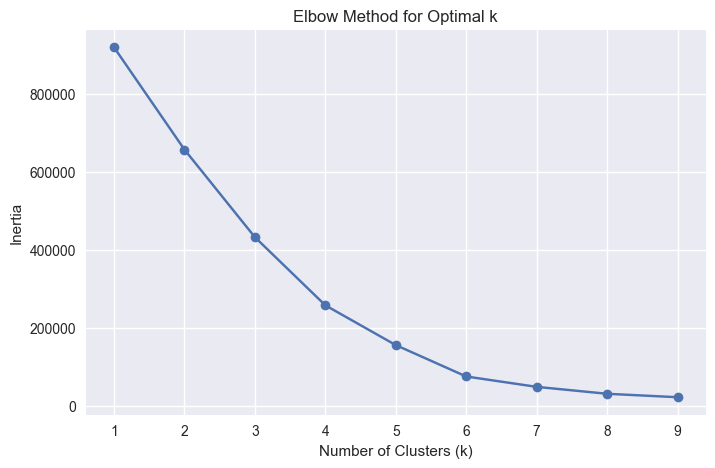

In [12]:
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [13]:
sample_data = df_cluster.sample(n=10000, random_state=42)

scaler = StandardScaler()
scaled_sample = scaler.fit_transform(sample_data)

In [14]:
sil_scores = {}

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm='elkan'
    )
    labels = kmeans.fit_predict(scaled_sample)
    sil = silhouette_score(scaled_sample, labels)
    sil_scores[k] = sil

sil_scores

{2: 0.4697693370129521,
 3: 0.5252277320563752,
 4: 0.6160763054093381,
 5: 0.7684673432192098,
 6: 0.9437963652989237,
 7: 0.9481719914490939}

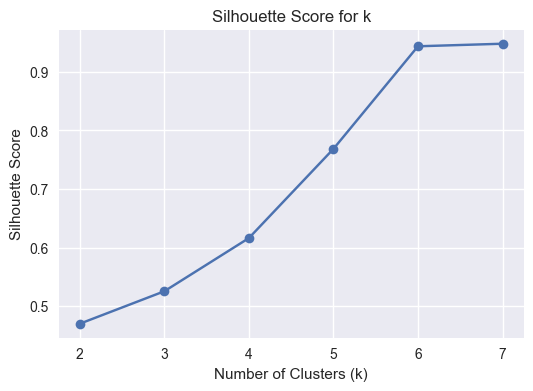

In [15]:
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for k")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(scaled_data)
df_cluster.head()

,HighBP,HighChol,Stroke,HeartDiseaseorAttack,Cluster
0,1,1,0,0,0
1,0,0,0,0,1
2,1,1,0,0,0
3,1,0,0,0,0
4,1,1,0,0,0


In [17]:
cluster_summary = df_cluster.groupby('Cluster')[['HighBP','HighChol','Stroke','HeartDiseaseorAttack']].mean()
cluster_summary

,HighBP,HighChol,Stroke,HeartDiseaseorAttack
Cluster,,,,
0,1.000000,0.587067,0.0,0.150674
1,0.000000,0.309947,0.0,0.042342
2,0.740665,0.646538,1.0,0.382730


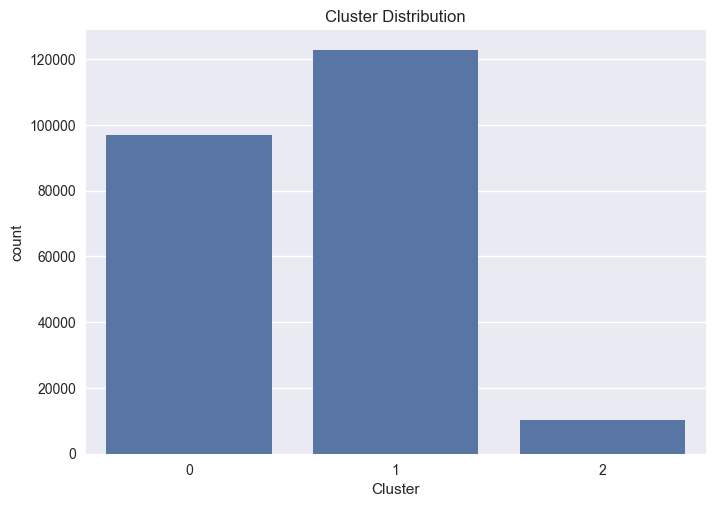

In [18]:
sns.countplot(x='Cluster', data=df_cluster)
plt.title("Cluster Distribution")
plt.show()

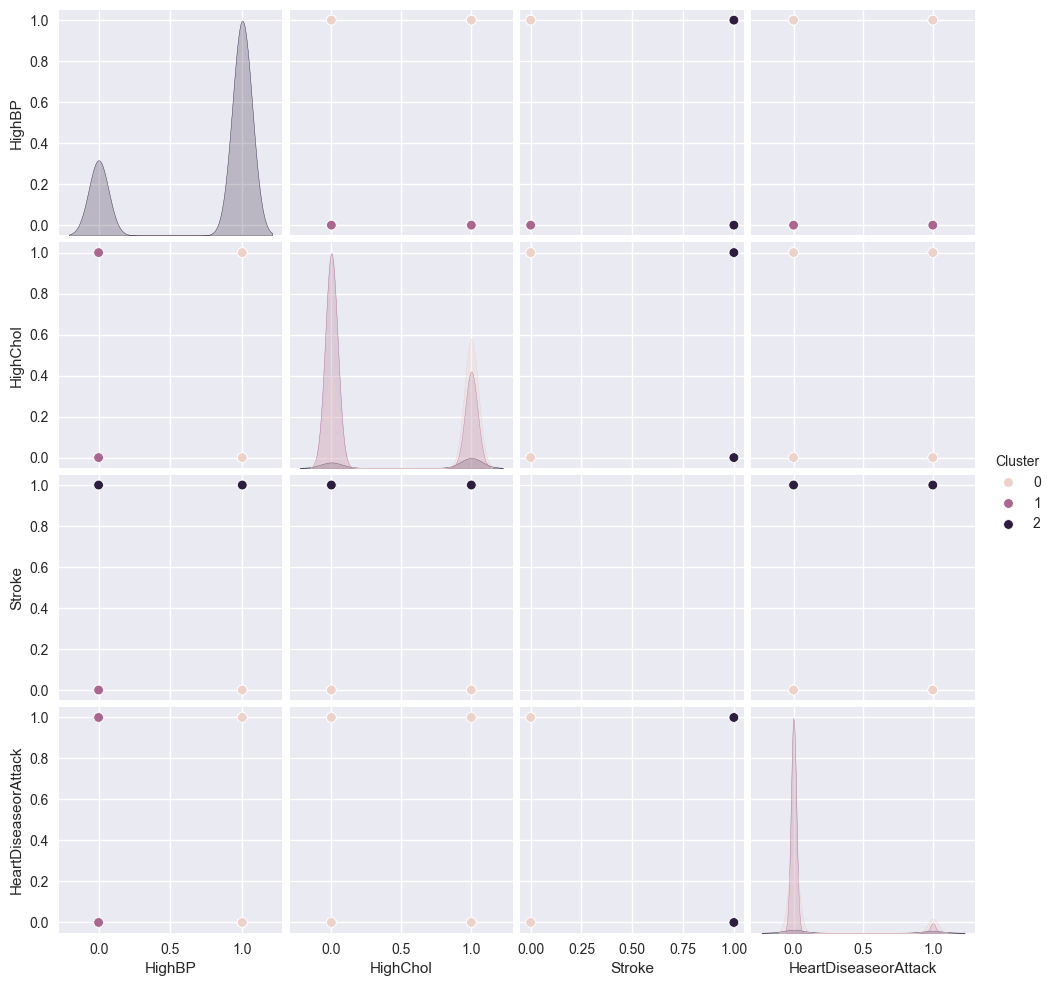

In [19]:
sns.pairplot(df_cluster, hue='Cluster')
plt.show()

In [20]:
df_cluster.to_csv("../results/tables/clustering_results.csv", index=False)
cluster_summary.to_csv("../results/tables/cluster_summary.csv")

### Overall Insights from Clustering

- The clustering clearly separates patients into low-risk, medium-risk, and high-risk groups.
- Stroke acts as a severity indicator, strongly defining the high-risk cluster.
- HighBP and HighChol dominate early and mid-risk clusters.
- HeartDiseaseorAttack prevalence increases as comorbidity burden increases.

### Overall Insights from Clustering

- The clustering clearly separates patients into low-risk, medium-risk, and high-risk groups.
- Stroke acts as a severity indicator, strongly defining the high-risk cluster.
- HighBP and HighChol dominate early and mid-risk clusters.

HeartDiseaseorAttack prevalence increases as comorbidity burden increases.